In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('students.csv')
print(f"Sample of the dataset:\n{df.head()}")
print(f"Dataset dimensions:\n{df.shape}")
print(f"Summary statistics:\n{df.describe()}")
print(f"Summary of categorical variables:\n{df.describe(include=['object'])}")

Sample of the dataset:
   stud.id                 name  gender  age  height  weight    religion  \
0   833917  Gonzales, Christina  Female   19     160    64.8      Muslim   
1   898539       Lozano, T'Hani  Female   19     172    73.0       Other   
2   379678       Williams, Hanh  Female   22     168    70.6  Protestant   
3   807564          Nem, Denzel    Male   19     183    79.7       Other   
4   383291      Powell, Heather  Female   21     175    71.4    Catholic   

   nc.score semester                   major                       minor  \
0      1.91      1st       Political Science             Social Sciences   
1      1.56      2nd         Social Sciences  Mathematics and Statistics   
2      1.24      3rd         Social Sciences  Mathematics and Statistics   
3      1.37      2nd  Environmental Sciences  Mathematics and Statistics   
4      1.46      1st  Environmental Sciences  Mathematics and Statistics   

   score1  score2  online.tutorial  graduated  salary  
0     N

# Q1: Draw a histogram of 'weight' and provide a short description of your observations with identifying the distribution

Text(0, 0.5, 'Frequency')

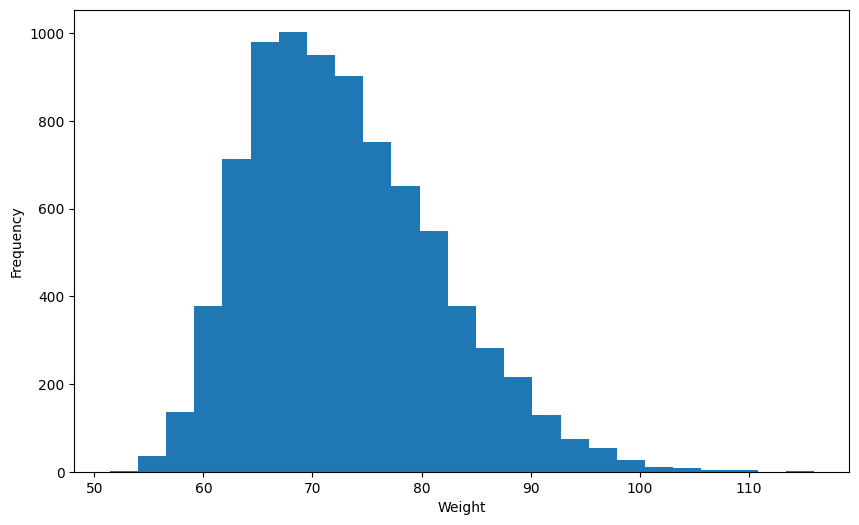

In [16]:
plt.figure(figsize=(10, 6))
plt.hist(x=df['weight'], bins=25)
plt.xlabel('Weight')
plt.ylabel('Frequency')

### Short description
+ The histogram shows that most people have lower weights, and only a few have higher weights. This means the data is skewed to the right (most values are on the lower side).

- 1- Skewness > 1 (Highly positively skewed)
- 2- Skewness < -1 (Highly negatively skewed)
- 3- 0.5 <skewness < 1 (Moderately positvely skewed)
- 4- - 1 <skewness < -0.5 (Moderately negatively skewed)
- 5- Generaly: if the skewness in columns range from -0.5 to 0.5
(Normally distributed)
What did you observe after exam

# Q2: Calculate the skewness of 'weight' and explain its significance

In [21]:
skewness = df['weight'].skew()
print("Skewness of weight:", skewness)

Skewness of weight: 0.651003964853539


+ The value is positive, so the data is right-skewed
+ The weight data is slightly skewed to the right, not perfectly symmetric.

# Q3: What is the probability that a student's weight is between 70 kg and 80 kg?

In [45]:
from scipy.stats import norm

mean_weight = df['weight'].mean()
std_weight = df['weight'].std()
print("Mean weight:", mean_weight)
print("Standard deviation of weight:", std_weight)

z_70 = (70 - mean_weight) / std_weight
print("Z-score for weight 70:", z_70)
z_80 = (80 - mean_weight) / std_weight
print("Z-score for weight 80:", z_80)

probability = norm.cdf(80, loc=mean_weight, scale=std_weight) - norm.cdf(70, loc=mean_weight, scale=std_weight)
print(f"Probability of a student weighing between 70 and 80 kg: {probability}")

Mean weight: 72.99813084112151
Standard deviation of weight: 8.63516168839212
Z-score for weight 70: -0.3472003130122934
Z-score for weight 80: 0.8108555938553885
Probability of a student weighing between 70 and 80 kg: 0.42705528013215555


# Q4: What is the probability that a student's weight is less than 70 Kg ?


In [46]:
probability_less_70 = norm.cdf(70, loc=mean_weight, scale=std_weight)
print(f"Probability of a student weighing less than 70 kg: {probability_less_70}")

Probability of a student weighing less than 70 kg: 0.36422041785029957


# Q5: What is the probability that a student's weight is greater than 70 kg?

In [47]:
probability_greater_70 = 1 - norm.cdf(70, loc=mean_weight, scale=std_weight)
print(f"Probability of a student weighing more than 70 kg: {probability_greater_70:.4f}")

Probability of a student weighing more than 70 kg: 0.6358


# Q6: A company produces electronic components, and their quality control process involves testing each component for defects. The defect rate for these components is 6%. The company recently received a large order for 300 components. They want to determine the probability of having a certain number of defective components in this order.

In [48]:
from scipy.stats import binom

n = 300
p = 0.06
k = 10
prob_exact_10 = binom.pmf(k, n, p)
print(f"Probability of exactly {k} defective components: {prob_exact_10}")

prob_at_most_20 = binom.cdf(20, n, p)
print(f"Probability of at most 20 defective components: {prob_at_most_20}")

prob_more_15 = 1 - binom.cdf(15, n, p)
print(f"Probability of more than 15 defective components: {prob_more_15}")

Probability of exactly 10 defective components: 0.013620614128121553
Probability of at most 20 defective components: 0.7357487590723666
Probability of more than 15 defective components: 0.7206685719451429


# Question 6.1: What is the probability that exactly 10 components out of an order of 300 are defective?

In [49]:
k = 10
prob_exact_10 = binom.pmf(k, n, p)
print(f"Probability of exactly {k} defective components: {prob_exact_10}")

Probability of exactly 10 defective components: 0.013620614128121553


# Question 6.2: What is the probability that minimum 10 components out of an order of 300 are defective?

In [50]:
prob_at_least_10 = 1 - binom.cdf(k-1, n, p)  # P(X >= 10) = 1 - P(X <= 9)
print(f"Probability of at least {k} defective components: {prob_at_least_10}")

Probability of at least 10 defective components: 0.9868069575023568


# Question 6.3: What is the probability that maximum 10 components out of an order of 300 are defective?

In [51]:
prob_at_most_10 = binom.cdf(k, n, p)
print(f"Probability of at most {k} defective components: {prob_at_most_10:.4f}")

Probability of at most 10 defective components: 0.0268


# Question 6.4: Calculate the number of components that are likely to be defective and the standard deviation of the defect probabilities for the 300 components.


In [54]:
expected_defective = n * p
std_defective = np.sqrt(n * p * (1 - p))
print(f"Expected number of defective components: {expected_defective}")
print(f"Standard deviation of defective components: {std_defective}")

Expected number of defective components: 18.0
Standard deviation of defective components: 4.113392760240626
